In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load ModelR datasets
print("Loading ModelR datasets...")

try:
    df_vnat = pd.read_csv('bandwidth_VNAT.csv')
    print(f"✓ Loaded bandwidth_VNAT.csv: {df_vnat.shape}")
except Exception as e:
    print(f"✗ Error loading bandwidth_VNAT.csv: {e}")
    df_vnat = pd.DataFrame()

try:
    df_generated_bw = pd.read_csv('bandwidth_generated.csv')
    print(f"✓ Loaded bandwidth_generated.csv: {df_generated_bw.shape}")
except Exception as e:
    print(f"✗ Error loading bandwidth_generated.csv: {e}")
    df_generated_bw = pd.DataFrame()

# Display first few rows
if not df_vnat.empty:
    print("\nVNAT Dataset Sample:")
    display(df_vnat.head())
    print(f"\nMissing values:\n{df_vnat.isnull().sum()}")

Loading ModelR datasets...
✓ Loaded bandwidth_VNAT.csv: (473, 17)
✓ Loaded bandwidth_generated.csv: (7473, 17)

VNAT Dataset Sample:


,mac_address,avg_packet_size,total_bytes,total_packets,flow_duration,bytes_per_second,packets_per_second,protocol_type,avg_inter_arrival_time,std_packet_size,unique_dst_ports,tcp_flag_ratio,payload_entropy,bidirectional_ratio,is_encrypted,time_of_day,bandwidth_kbps
0,08:ad:d1:4c:bc:83,257.481928,21371,83,1146.227174,18.644646,0.072411,1,13978.380170,286.383783,2,1.000000,1.843274,0.5,0,19,0.149157
1,a4:ac:94:fb:21:ad,316.072289,26234,83,1146.271047,22.886385,0.072409,1,13978.915210,345.963289,1,1.000000,1.983849,0.5,0,19,0.183091
2,1c:cb:6d:89:7c:bb,194.818182,2143,11,10.696647,200.343156,1.028360,1,1069.664693,137.114960,1,1.090909,1.846220,0.5,0,19,1.602745
3,08:ad:d1:4c:bc:83,156.311836,567841,2743,3598.791145,52.715761,0.254975,1,289827.347600,84.767874,8,0.333944,1.038133,0.5,0,2,0.421726
4,f4:6d:c8:70:ac:43,72.500000,145,2,485.770607,0.298495,0.004117,2,485770.607000,1.500000,1,0.000000,0.693147,0.5,0,2,0.002388



Missing values:
mac_address               0
avg_packet_size           0
total_bytes               0
total_packets             0
flow_duration             0
bytes_per_second          0
packets_per_second        0
protocol_type             0
avg_inter_arrival_time    0
std_packet_size           0
unique_dst_ports          0
tcp_flag_ratio            0
payload_entropy           0
bidirectional_ratio       0
is_encrypted              0
time_of_day               0
bandwidth_kbps            0
dtype: int64


In [4]:
# Load ModelA datasets
print("Loading ModelA datasets...")

try:
    df_cic = pd.read_csv('anomaly_CIC-IDS.csv')
    print(f"✓ Loaded anomaly_CIC-IDS.csv: {df_cic.shape}")
except Exception as e:
    print(f"✗ Error loading anomaly_CIC-IDS.csv: {e}")
    df_cic = pd.DataFrame()

try:
    df_generated_anom = pd.read_csv('anomaly_generated.csv')
    print(f"✓ Loaded anomaly_generated.csv: {df_generated_anom.shape}")
except Exception as e:
    print(f"✗ Error loading anomaly_generated.csv: {e}")
    df_generated_anom = pd.DataFrame()

# Display first few rows
if not df_cic.empty:
    print("\nCIC-IDS Dataset Sample:")
    display(df_cic.head())
    print(f"\nMissing values:\n{df_cic.isnull().sum()}")

Loading ModelA datasets...
✓ Loaded anomaly_CIC-IDS.csv: (273381, 23)
✓ Loaded anomaly_generated.csv: (12000, 23)

CIC-IDS Dataset Sample:


,mac_address,total_bytes,total_packets,flow_duration,bytes_per_second,packets_per_second,avg_packet_size,std_packet_size,packet_size_variance,avg_inter_arrival_time,...,unique_src_ports,is_encrypted,tcp_flag_ratio,payload_entropy,bidirectional_ratio,time_of_day,connection_rate,failed_connection_ratio,port_scan_indicator,is_anomaly
0,mac_Friday-WorkingHours-Afternoon-DDos.csv_0,12,2,3.0,4.000000,0.666667,9.0,0.0,0.0,3.0,...,1.0,0.0,0.5,NaN,1.0,-1.0,NaN,NaN,0.0,0.0
1,mac_Friday-WorkingHours-Afternoon-DDos.csv_1,12,2,109.0,0.110092,0.018349,9.0,0.0,0.0,109.0,...,1.0,0.0,0.5,NaN,0.5,-1.0,NaN,NaN,0.0,0.0
2,mac_Friday-WorkingHours-Afternoon-DDos.csv_2,12,2,52.0,0.230769,0.038462,9.0,0.0,0.0,52.0,...,1.0,0.0,0.5,NaN,0.5,-1.0,NaN,NaN,0.0,0.0
3,mac_Friday-WorkingHours-Afternoon-DDos.csv_3,12,2,34.0,0.352941,0.058824,9.0,0.0,0.0,34.0,...,1.0,0.0,0.5,NaN,0.5,-1.0,NaN,NaN,0.0,0.0
4,mac_Friday-WorkingHours-Afternoon-DDos.csv_4,12,2,3.0,4.000000,0.666667,9.0,0.0,0.0,3.0,...,1.0,0.0,0.5,NaN,1.0,-1.0,NaN,NaN,0.0,0.0



Missing values:
mac_address                     0
total_bytes                     0
total_packets                   0
flow_duration                   0
bytes_per_second                8
packets_per_second              0
avg_packet_size                 1
std_packet_size                 1
packet_size_variance            1
avg_inter_arrival_time          1
protocol_type                   1
protocol_diversity              1
unique_dst_ports                1
unique_src_ports                1
is_encrypted                    1
tcp_flag_ratio                  1
payload_entropy            273381
bidirectional_ratio          8698
time_of_day                     1
connection_rate            273381
failed_connection_ratio    273381
port_scan_indicator             1
is_anomaly                      1
dtype: int64


In [8]:
def clean_bandwidth_data(df, dataset_name=""):
    """
    Clean and prepare bandwidth prediction dataset (ModelR)
    """
    print(f"\nCleaning {dataset_name}...")
    df = df.copy()

    # Expected columns for ModelR
    expected_cols = ['mac_address', 'avg_packet_size', 'total_bytes', 'total_packets',
                     'flow_duration', 'bytes_per_second', 'packets_per_second',
                     'protocol_type', 'avg_inter_arrival_time', 'std_packet_size',
                     'unique_dst_ports', 'tcp_flag_ratio', 'payload_entropy',
                     'bidirectional_ratio', 'is_encrypted', 'time_of_day', 'bandwidth_kbps']

    # Keep only expected columns that exist
    available_cols = [col for col in expected_cols if col in df.columns]
    df = df[available_cols]

    print(f"  Initial shape: {df.shape}")

    # Handle missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)

    # Fill categorical missing values
    if 'mac_address' in df.columns:
        df['mac_address'].fillna('unknown', inplace=True)

    # Remove rows with infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    # Ensure target variable is positive
    if 'bandwidth_kbps' in df.columns:
        df = df[df['bandwidth_kbps'] > 0]

    print(f"  Final shape: {df.shape}")
    print(f"  Missing values: {df.isnull().sum().sum()}")

    return df


def clean_anomaly_data(df, dataset_name=""):
    """
    Clean and prepare anomaly detection dataset (ModelA)
    """
    print(f"\nCleaning {dataset_name}...")
    df = df.copy()

    # Expected columns for ModelA
    expected_cols = ['mac_address', 'total_bytes', 'total_packets', 'flow_duration',
                     'bytes_per_second', 'packets_per_second', 'avg_packet_size',
                     'std_packet_size', 'packet_size_variance', 'avg_inter_arrival_time',
                     'protocol_type', 'protocol_diversity', 'unique_dst_ports',
                     'unique_src_ports', 'is_encrypted', 'tcp_flag_ratio',
                     'payload_entropy', 'bidirectional_ratio', 'time_of_day',
                     'connection_rate', 'failed_connection_ratio', 'port_scan_indicator',
                     'is_anomaly']

    # Keep only expected columns that exist
    available_cols = [col for col in expected_cols if col in df.columns]
    df = df[available_cols]

    print(f"  Initial shape: {df.shape}")

    # Drop columns that are entirely NaN
    cols_to_drop_due_to_all_nan = df.columns[df.isnull().all()].tolist()
    if cols_to_drop_due_to_all_nan:
        print(f"  Dropping entirely NaN columns: {cols_to_drop_due_to_all_nan}")
        df.drop(columns=cols_to_drop_due_to_all_nan, inplace=True)

    # Handle missing values for remaining columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)

    # Fill categorical missing values
    if 'mac_address' in df.columns:
        df['mac_address'].fillna('unknown', inplace=True)

    # Ensure is_anomaly is binary
    if 'is_anomaly' in df.columns:
        df['is_anomaly'] = df['is_anomaly'].astype(int)

    # Remove rows with infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True) # This dropna should now only affect rows with *some* remaining NaNs

    print(f"  Final shape: {df.shape}")
    print(f"  Missing values: {df.isnull().sum().sum()}")

    return df

print("Data preparation functions defined!")

Data preparation functions defined!


In [6]:
# Clean VNAT dataset (messy data)
if not df_vnat.empty:
    df_vnat_clean = clean_bandwidth_data(df_vnat, "VNAT Dataset")
else:
    df_vnat_clean = pd.DataFrame()

# Clean generated dataset (minimal cleaning needed)
if not df_generated_bw.empty:
    df_generated_bw_clean = clean_bandwidth_data(df_generated_bw, "Generated Bandwidth Dataset")
else:
    df_generated_bw_clean = pd.DataFrame()

# Combine datasets for ModelR
if not df_vnat_clean.empty and not df_generated_bw_clean.empty:
    df_modelr = pd.concat([df_vnat_clean, df_generated_bw_clean], ignore_index=True)
elif not df_vnat_clean.empty:
    df_modelr = df_vnat_clean
elif not df_generated_bw_clean.empty:
    df_modelr = df_generated_bw_clean
else:
    df_modelr = pd.DataFrame()

print(f"\n{'='*50}")
print(f"Combined ModelR Dataset Shape: {df_modelr.shape}")
print(f"{'='*50}")

if not df_modelr.empty:
    print("\nBandwidth Statistics:")
    print(df_modelr['bandwidth_kbps'].describe())


Cleaning VNAT Dataset...
  Initial shape: (473, 17)
  Final shape: (473, 17)
  Missing values: 0

Cleaning Generated Bandwidth Dataset...
  Initial shape: (7473, 17)
  Final shape: (7473, 17)
  Missing values: 0

Combined ModelR Dataset Shape: (7946, 17)

Bandwidth Statistics:
count      7946.000000
mean        868.395700
std        4366.997425
min           0.000569
25%          25.256500
50%         163.234929
75%         889.753555
max      264556.832500
Name: bandwidth_kbps, dtype: float64


In [9]:
# Clean CIC-IDS dataset (messy data)
if not df_cic.empty:
    df_cic_clean = clean_anomaly_data(df_cic, "CIC-IDS Dataset")
else:
    df_cic_clean = pd.DataFrame()

# Clean generated anomaly dataset
if not df_generated_anom.empty:
    df_generated_anom_clean = clean_anomaly_data(df_generated_anom, "Generated Anomaly Dataset")
else:
    df_generated_anom_clean = pd.DataFrame()

# Combine datasets for ModelA
if not df_cic_clean.empty and not df_generated_anom_clean.empty:
    df_modela = pd.concat([df_cic_clean, df_generated_anom_clean], ignore_index=True)
elif not df_cic_clean.empty:
    df_modela = df_cic_clean
elif not df_generated_anom_clean.empty:
    df_modela = df_generated_anom_clean
else:
    df_modela = pd.DataFrame()

print(f"\n{'='*50}")
print(f"Combined ModelA Dataset Shape: {df_modela.shape}")
print(f"{'='*50}")

if not df_modela.empty and 'is_anomaly' in df_modela.columns:
    print("\nAnomaly Distribution:")
    print(df_modela['is_anomaly'].value_counts())
    print(f"\nAnomaly Rate: {df_modela['is_anomaly'].mean():.2%}")


Cleaning CIC-IDS Dataset...
  Initial shape: (273381, 23)
  Dropping entirely NaN columns: ['payload_entropy', 'connection_rate', 'failed_connection_ratio']
  Final shape: (273328, 20)
  Missing values: 0

Cleaning Generated Anomaly Dataset...
  Initial shape: (12000, 23)
  Final shape: (12000, 23)
  Missing values: 0

Combined ModelA Dataset Shape: (285328, 23)

Anomaly Distribution:
is_anomaly
0    153069
1    132259
Name: count, dtype: int64

Anomaly Rate: 46.35%


In [11]:
bandwidth_features = ['avg_packet_size', 'total_bytes', 'total_packets', 'flow_duration',
                      'bytes_per_second', 'packets_per_second', 'protocol_type',
                      'avg_inter_arrival_time', 'std_packet_size', 'unique_dst_ports',
                      'tcp_flag_ratio', 'payload_entropy', 'bidirectional_ratio',
                      'is_encrypted', 'time_of_day']

anomaly_features = ['avg_packet_size', 'total_bytes', 'total_packets', 'flow_duration',
                    'bytes_per_second', 'packets_per_second', 'protocol_type',
                    'avg_inter_arrival_time', 'std_packet_size', 'unique_dst_ports',
                    'tcp_flag_ratio', 'payload_entropy', 'bidirectional_ratio',
                    'is_encrypted', 'time_of_day', 'connection_rate',
                    'failed_connection_ratio', 'port_scan_indicator',
                    'packet_size_variance', 'protocol_diversity']

# 1. Create a unified feature space (union of all relevant features)
all_model_features_set = set(bandwidth_features) | set(anomaly_features)

# Exclude obviously non-numeric/categorical features that are not yet encoded
# 'mac_address' is typically handled as an ID or one-hot encoded, not scaled directly
# 'protocol_type' is a categorical feature, should be one-hot encoded before scaling
features_to_exclude_from_scaling = ['mac_address', 'protocol_type']

# Filter the unified feature space to include only those suitable for direct numerical scaling
common_numeric_features_for_scaling = sorted([
    f for f in all_model_features_set
    if f not in features_to_exclude_from_scaling
])

all_features_data_for_scaling = []

if not df_modelr.empty:
    # Create a DataFrame for df_modelr with the common numeric features
    df_modelr_aligned_for_scaling = pd.DataFrame(0.0, index=df_modelr.index, columns=common_numeric_features_for_scaling)

    # Fill existing features from df_modelr
    for feature in common_numeric_features_for_scaling:
        if feature in df_modelr.columns:
            df_modelr_aligned_for_scaling[feature] = df_modelr[feature]

    all_features_data_for_scaling.append(df_modelr_aligned_for_scaling.values)

if not df_modela.empty:
    # Create a DataFrame for df_modela with the common numeric features
    df_modela_aligned_for_scaling = pd.DataFrame(0.0, index=df_modela.index, columns=common_numeric_features_for_scaling)

    # Fill existing features from df_modela
    for feature in common_numeric_features_for_scaling:
        if feature in df_modela.columns:
            df_modela_aligned_for_scaling[feature] = df_modela[feature]

    all_features_data_for_scaling.append(df_modela_aligned_for_scaling.values)

# Fit scaler on combined data
if len(all_features_data_for_scaling) > 0:
    all_features_array = np.vstack(all_features_data_for_scaling)
    scaler = StandardScaler()
    scaler.fit(all_features_array)
    print(f"✓ StandardScaler fitted on {all_features_array.shape[0]} samples")
    print(f"  Feature dimensions: {all_features_array.shape[1]}")
else:
    print("✗ No features available for scaling")
    scaler = StandardScaler()

✓ StandardScaler fitted on 293274 samples
  Feature dimensions: 19


In [13]:
if not df_modelr.empty and 'bandwidth_kbps' in df_modelr.columns:
    print("Training ModelR (Bandwidth Predictor)...\n")

    # Prepare features and target
    # Use common_numeric_features_for_scaling for X_bw to match the scaler's expected features
    X_bw_aligned = pd.DataFrame(0.0, index=df_modelr.index, columns=common_numeric_features_for_scaling)
    for feature in common_numeric_features_for_scaling:
        if feature in df_modelr.columns:
            X_bw_aligned[feature] = df_modelr[feature]

    y_bw = df_modelr['bandwidth_kbps']

    # Scale features using the pre-fitted scaler
    X_bw_scaled = scaler.transform(X_bw_aligned)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_bw_scaled, y_bw, test_size=0.2, random_state=42
    )

    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples\n")

    # Train RandomForestRegressor
    model_r = RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model_r.fit(X_train, y_train)
    print("✓ Model training complete!\n")

    # Evaluate
    y_pred = model_r.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("Model Performance:")
    print(f"  RMSE: {rmse:.2f} kbps")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Absolute Error: {np.mean(np.abs(y_test - y_pred)):.2f} kbps")

    # Feature importance - Note: this will still use available_bw_features for labeling,
    # but the model was trained on 19 features (some of which were 0 for df_modelr).
    # For accurate feature importance relative to the 19 features, we'd need to align this too.
    # For now, keeping it based on original bandwidth_features as it's typically more relevant.
    feature_importance = pd.DataFrame({
        'feature': available_bw_features,
        'importance': model_r.feature_importances_[:len(available_bw_features)] # Take only relevant importances
    }).sort_values('importance', ascending=False)

    print("\nTop 10 Important Features:")
    print(feature_importance.head(10))

else:
    print("✗ Cannot train ModelR: No bandwidth data available")
    model_r = None

Training ModelR (Bandwidth Predictor)...

Training set: 6356 samples
Test set: 1590 samples

✓ Model training complete!

Model Performance:
  RMSE: 4658.48 kbps
  R² Score: 0.5208
  Mean Absolute Error: 379.97 kbps

Top 10 Important Features:
                   feature  importance
1              total_bytes    0.373238
3            flow_duration    0.243926
9         unique_dst_ports    0.188824
6            protocol_type    0.131707
10          tcp_flag_ratio    0.005906
13            is_encrypted    0.004930
14             time_of_day    0.004714
0          avg_packet_size    0.002780
7   avg_inter_arrival_time    0.000721
2            total_packets    0.000000


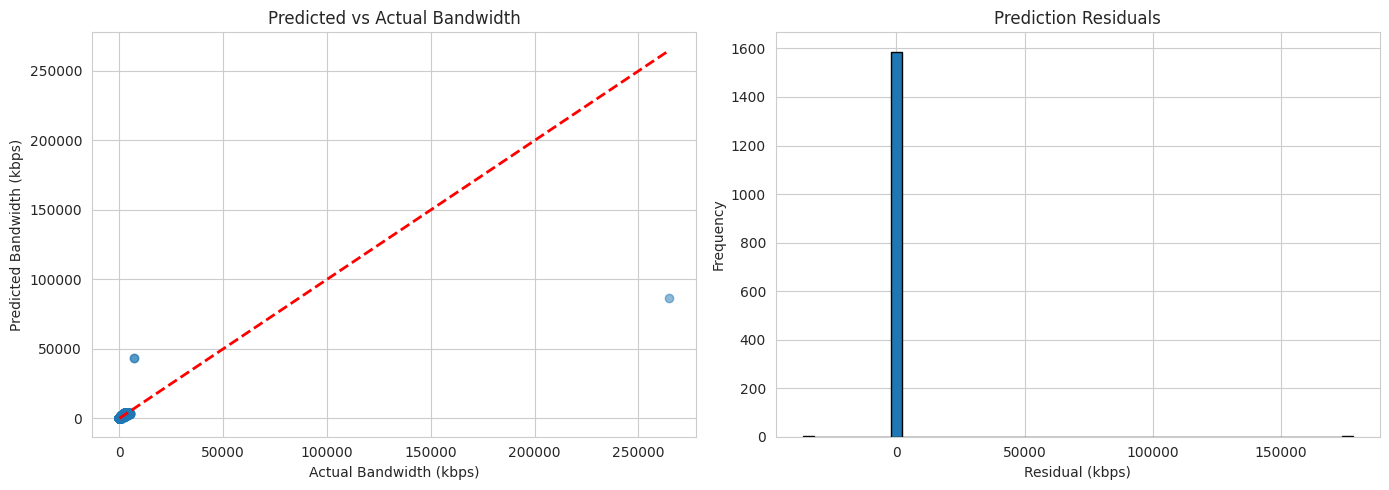

In [14]:
if model_r is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Predicted vs Actual
    axes[0].scatter(y_test, y_pred, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual Bandwidth (kbps)')
    axes[0].set_ylabel('Predicted Bandwidth (kbps)')
    axes[0].set_title('Predicted vs Actual Bandwidth')
    axes[0].grid(True)

    # Residuals
    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=50, edgecolor='black')
    axes[1].set_xlabel('Residual (kbps)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Prediction Residuals')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [16]:
if not df_modela.empty:
    print("Training ModelA (Anomaly Detector)...\n")

    # Prepare features (exclude is_anomaly for training)
    # Align X_anom to the common numeric features used for scaler fitting
    X_anom_aligned = pd.DataFrame(0.0, index=df_modela.index, columns=common_numeric_features_for_scaling)
    for feature in common_numeric_features_for_scaling:
        if feature in df_modela.columns:
            X_anom_aligned[feature] = df_modela[feature]

    # Scale features
    X_anom_scaled = scaler.transform(X_anom_aligned)

    print(f"Training samples: {X_anom_scaled.shape[0]}")
    print(f"Features: {X_anom_scaled.shape[1]}\n")

    # Determine contamination rate from data
    if 'is_anomaly' in df_modela.columns:
        contamination = df_modela['is_anomaly'].mean()
        contamination = max(0.01, min(0.5, contamination))  # Clamp between 1% and 50%
    else:
        contamination = 0.1  # Default 10%

    print(f"Using contamination rate: {contamination:.2%}\n")

    # Train IsolationForest
    model_a = IsolationForest(
        n_estimators=100,
        max_samples='auto',
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )

    model_a.fit(X_anom_scaled)
    print("✓ Model training complete!\n")

    # Evaluate if labels are available
    if 'is_anomaly' in df_modela.columns:
        y_true = df_modela['is_anomaly']
        y_pred = model_a.predict(X_anom_scaled)
        y_pred_binary = (y_pred == -1).astype(int)  # Convert -1/1 to 0/1

        accuracy = accuracy_score(y_true, y_pred_binary)
        f1 = f1_score(y_true, y_pred_binary)

        print("Model Performance:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  F1 Score: {f1:.4f}")
        print(f"  Anomalies Detected: {y_pred_binary.sum()} / {len(y_pred_binary)}")
        print(f"  True Anomalies: {y_true.sum()}\n")

        print("Classification Report:")
        print(classification_report(y_true, y_pred_binary, target_names=['Normal', 'Anomaly']))

else:
    print("✗ Cannot train ModelA: No anomaly data available")
    model_a = None

Training ModelA (Anomaly Detector)...

Training samples: 285328
Features: 19

Using contamination rate: 46.35%

✓ Model training complete!

Model Performance:
  Accuracy: 0.5863
  F1 Score: 0.5532
  Anomalies Detected: 131977 / 285328
  True Anomalies: 132259

Classification Report:
              precision    recall  f1-score   support

      Normal       0.61      0.62      0.61    153069
     Anomaly       0.55      0.55      0.55    132259

    accuracy                           0.59    285328
   macro avg       0.58      0.58      0.58    285328
weighted avg       0.59      0.59      0.59    285328



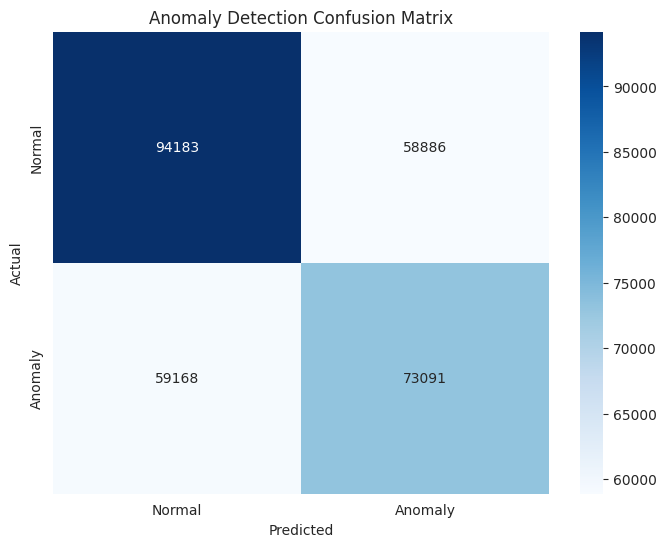

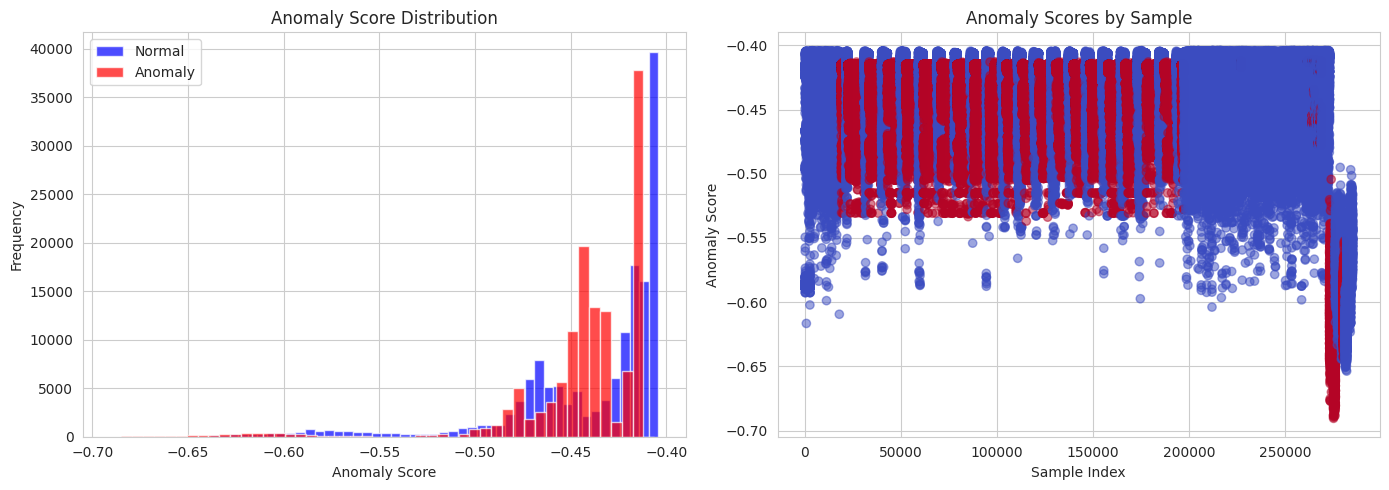

In [17]:
if model_a is not None and 'is_anomaly' in df_modela.columns:
    from sklearn.metrics import confusion_matrix

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_binary)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Anomaly Detection Confusion Matrix')
    plt.show()

    # Anomaly Score Distribution
    anomaly_scores = model_a.score_samples(X_anom_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(anomaly_scores[y_true == 0], bins=50, alpha=0.7, label='Normal', color='blue')
    axes[0].hist(anomaly_scores[y_true == 1], bins=50, alpha=0.7, label='Anomaly', color='red')
    axes[0].set_xlabel('Anomaly Score')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Anomaly Score Distribution')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].scatter(range(len(anomaly_scores)), anomaly_scores,
                   c=y_true, cmap='coolwarm', alpha=0.5)
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('Anomaly Score')
    axes[1].set_title('Anomaly Scores by Sample')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [18]:
import os

# Create a directory to save models if it doesn't exist
models_dir = '/models'
os.makedirs(models_dir, exist_ok=True)
print(f"Created directory: {models_dir}")

Created directory: /models


In [20]:
# Save the fitted StandardScaler
if 'scaler' in locals() and scaler is not None:
    joblib.dump(scaler, os.path.join(models_dir, 'feature_scaler.pkl'))
    print(f"Feature scaler saved to {os.path.join(models_dir, 'feature_scaler.pkl')}")
else:
    print("Scaler object not found or is None.")

# Save the trained bandwidth predictor (ModelR)
if 'model_r' in locals() and model_r is not None:
    joblib.dump(model_r, os.path.join(models_dir, 'bandwidth_predictor.pkl'))
    print(f"Bandwidth predictor saved to {os.path.join(models_dir, 'bandwidth_predictor.pkl')}")
else:
    print("Bandwidth predictor model (model_r) not found or is None.")

# Save the trained anomaly detector (ModelA)
if 'model_a' in locals() and model_a is not None:
    joblib.dump(model_a, os.path.join(models_dir, 'anomaly_detector.pkl'))
    print(f"Anomaly detector saved to {os.path.join(models_dir, 'anomaly_detector.pkl')}")
else:
    print("Anomaly detector model (model_a) not found or is None.")

Feature scaler saved to /models/feature_scaler.pkl
Bandwidth predictor saved to /models/bandwidth_predictor.pkl
Anomaly detector saved to /models/anomaly_detector.pkl


In [22]:
import os
os.makedirs("/content/models", exist_ok=True)

!cp /models/*.pkl /content/models/

In [23]:
import os

# List contents of the /models directory
models_dir = '/models'
if os.path.exists(models_dir):
    print(f"Contents of {models_dir}:")
    for item in os.listdir(models_dir):
        print(f"- {item}")
else:
    print(f"Directory {models_dir} does not exist.")

Contents of /models:
- feature_scaler.pkl
- anomaly_detector.pkl
- bandwidth_predictor.pkl


In [24]:
from google.colab import files
files.download('/models/feature_scaler.pkl')
files.download('/models/anomaly_detector.pkl')
files.download('/models/bandwidth_predictor.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>